In [1]:


import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from common.dataset import ZooScanImageFolder

import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import random
from common.transforms import apply_clahe, resize_and_pad, ResizeAndPad
import albumentations as A
from transformers import SwinForImageClassification, SwinConfig
from albumentations.pytorch import ToTensorV2
import torch.nn as nn

/cluster/home/katjasi/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:albumentations.check_version:A new version of Albumentations is available: 1.4.24 (you have 1.4.11). Upgrade using: pip install --upgrade albumentations


In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


MODEL_PATH = "../checkpoints/swin_contrastive_3/best_checkpoint.pth"
DATA_ROOT = "datasets/ZooScan77_010/val"
NUM_CLASSES = 77
BATCH_SIZE = 32

transform = A.Compose([
        ResizeAndPad(size=224, fill=255),
        A.Normalize(mean=[0.9044 , 0.9044, 0.9044], std= [0.1485 , 0.1485, 0.1485]),
        ToTensorV2()
    ])
      

Using device: cuda


In [3]:
dataset = ZooScanImageFolder(root='../datasets/ZooScan77_010/val', transform=transform, grayscale=False)
data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
model = SwinForImageClassification.from_pretrained("microsoft/swin-base-patch4-window7-224",
                                                       num_labels=77,
                                                       ignore_mismatched_sizes=True)
model.classifier = nn.Identity()
model = model.to(device)
model = nn.DataParallel(model)
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"], strict=False)
model.eval()
model.to(device)

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-base-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([77]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 1024]) in the checkpoint and torch.Size([77, 1024]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DataParallel(
  (module): SwinForImageClassification(
    (swin): SwinModel(
      (embeddings): SwinEmbeddings(
        (patch_embeddings): SwinPatchEmbeddings(
          (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
        )
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): SwinEncoder(
        (layers): ModuleList(
          (0): SwinStage(
            (blocks): ModuleList(
              (0-1): 2 x SwinLayer(
                (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
                (attention): SwinAttention(
                  (self): SwinSelfAttention(
                    (query): Linear(in_features=128, out_features=128, bias=True)
                    (key): Linear(in_features=128, out_features=128, bias=True)
                    (value): Linear(in_features=128, out_features=128, bias=True)
                    (dropout): Dropout(p=0.0, in

In [4]:
model_ = SwinForImageClassification.from_pretrained("microsoft/swin-base-patch4-window7-224",
                                                       num_labels=77,
                                                       ignore_mismatched_sizes=True)
model_.classifier = nn.Identity()
model_ = model_.to(device)
model_.eval()
model_.to(device)

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-base-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([77]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 1024]) in the checkpoint and torch.Size([77, 1024]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0-1): 2 x SwinLayer(
              (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (attention): SwinAttention(
                (self): SwinSelfAttention(
                  (query): Linear(in_features=128, out_features=128, bias=True)
                  (key): Linear(in_features=128, out_features=128, bias=True)
                  (value): Linear(in_features=128, out_features=128, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
                (output): SwinSelfO

In [5]:
all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, labels in data_loader:
        images = images.to(device)
        feats = model(images)
        all_embeddings.append(feats.logits.cpu())
        all_labels.append(labels.cpu())
        

In [6]:
all_embeddings_ = []
all_labels_ = []

with torch.no_grad():
    for images, labels in data_loader:
        images = images.to(device)
        feats = model_(images)
        all_embeddings_.append(feats.logits.cpu())
        all_labels_.append(labels.cpu())
        

In [7]:
all_embeddings = torch.cat(all_embeddings, dim=0).numpy()  # (N, D)
all_labels = torch.cat(all_labels, dim=0).numpy()          # (N, )

print("Embedding shape:", all_embeddings.shape)
print("Label shape:", all_labels.shape)


Embedding shape: (19494, 1024)
Label shape: (19494,)


In [8]:
all_embeddings_ = torch.cat(all_embeddings_, dim=0).numpy()  # (N, D)
all_labels_ = torch.cat(all_labels_, dim=0).numpy()          # (N, )

print("Embedding shape:", all_embeddings_.shape)
print("Label shape:", all_labels_.shape)


Embedding shape: (19494, 1024)
Label shape: (19494,)


Completed t-SNE, resulting shape: (19494, 2)


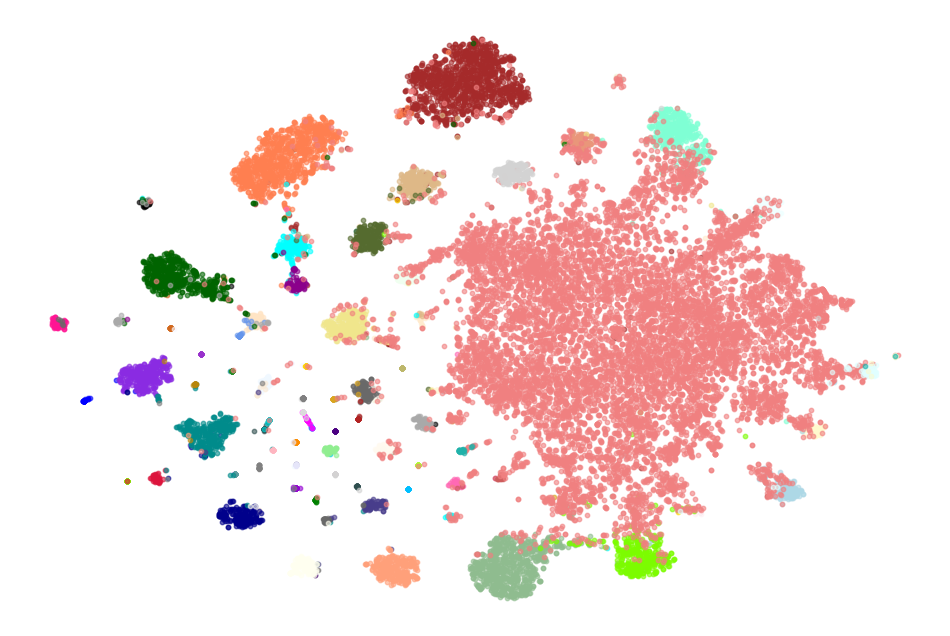

In [10]:

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_2d = tsne.fit_transform(all_embeddings)  # shape: (N, 2)

print("Completed t-SNE, resulting shape:", X_2d.shape)
plt.figure(figsize=(12, 8))
import matplotlib.colors as mcolors
colors_list = list(mcolors.CSS4_COLORS.keys())  

for class_id in range(NUM_CLASSES):
    idx = (all_labels == class_id)
    if np.sum(idx) == 0:
        continue  
    color = colors_list[class_id % len(colors_list)]  # cycle if needed
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1],
                label=f"Class {class_id}",
                color=color,
                alpha=0.6,
                s=10)

#plt.title("t-SNE visualization of embeddings (77 classes)")
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
#plt.tight_layout()
plt.axis('off')
plt.savefig("tsne_contr.png", dpi=300, bbox_inches='tight')
plt.show()

Selected classes: [7, 13, 27, 32, 33, 35, 54, 58, 66, 74]
Filtered embeddings shape: (494, 1024)
Filtered labels shape: (494,)


Completed t-SNE on selected classes, resulting shape: (494, 2)


/tmp/ipykernel_1101248/2739602846.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


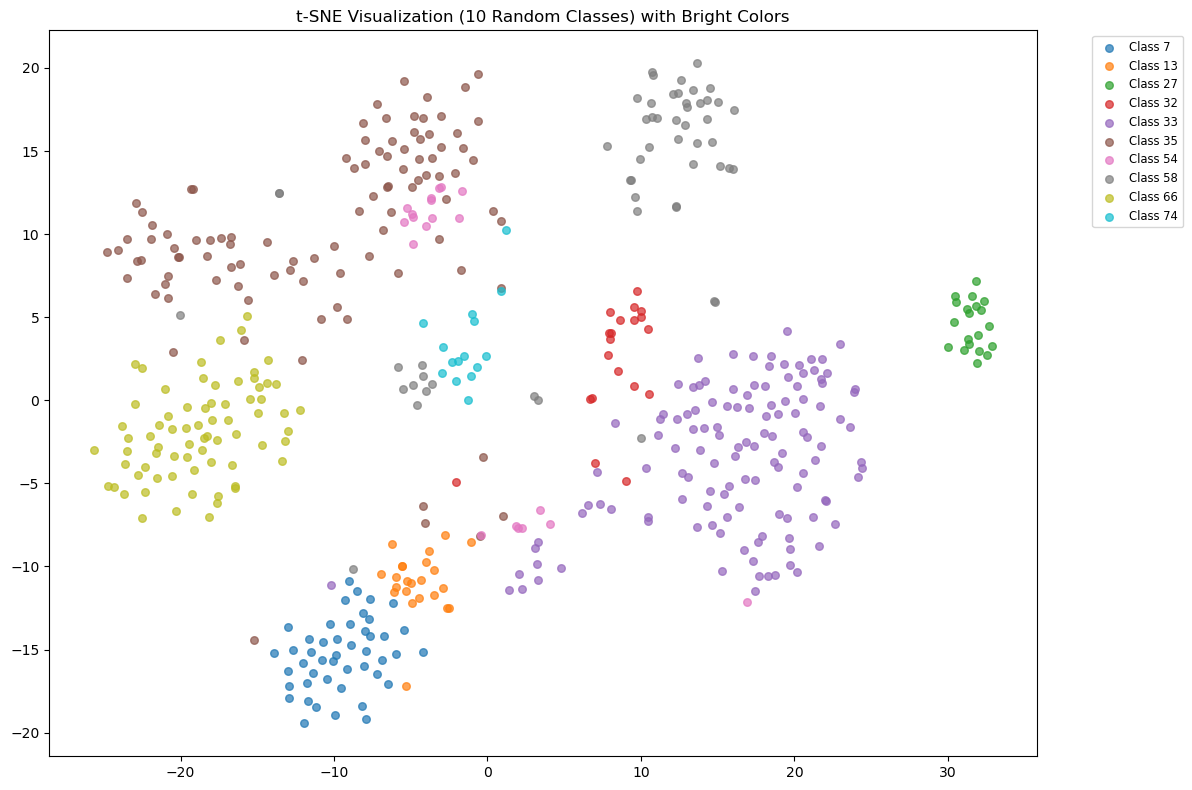

In [11]:
selected_classes = random.sample(range(NUM_CLASSES), 10)
selected_classes.sort()  # optional: sort for consistent ordering
print("Selected classes:", selected_classes)



Filtered embeddings shape: (494, 1024)
Filtered labels shape: (494,)
Completed t-SNE on selected classes, resulting shape: (494, 2)


/tmp/ipykernel_1101248/2609969009.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


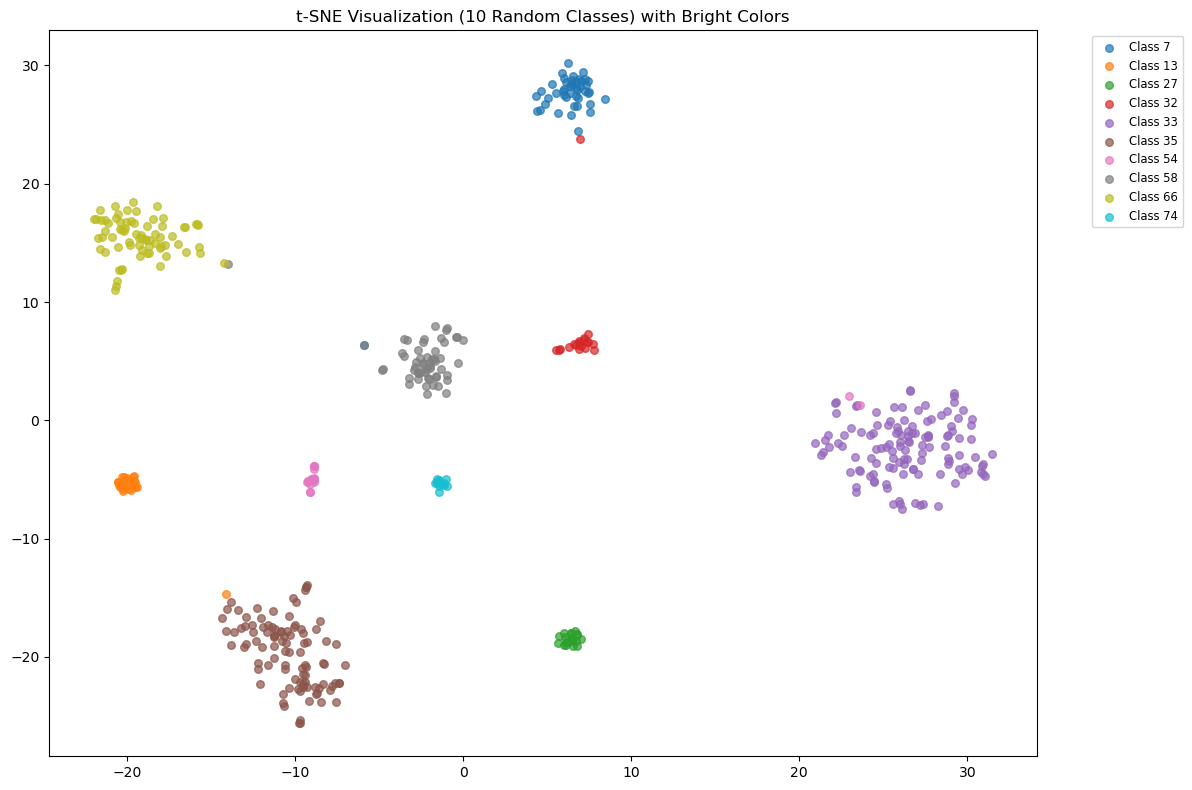

In [16]:

idx = np.isin(all_labels, selected_classes)  # boolean array
filtered_embeddings = all_embeddings[idx]     # shape: (N_filtered, D)
filtered_labels = all_labels[idx]             # shape: (N_filtered,)

print("Filtered embeddings shape:", filtered_embeddings.shape)
print("Filtered labels shape:", filtered_labels.shape)

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_2d = tsne.fit_transform(filtered_embeddings)
print("Completed t-SNE on selected classes, resulting shape:", X_2d.shape)


plt.figure(figsize=(12, 8))

cmap = plt.cm.get_cmap('tab10', 10)

for i, class_id in enumerate(selected_classes):
    class_idx = (filtered_labels == class_id)
    # Get a color from 'tab10' for the i-th class
    color = cmap(i)
    plt.scatter(X_2d[class_idx, 0],
                X_2d[class_idx, 1],
                label=f"Class {class_id}",
                color=color,
                alpha=0.7,
                s=30)

plt.title("t-SNE Visualization (10 Random Classes) with Bright Colors")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize='small')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1101248/433143202.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


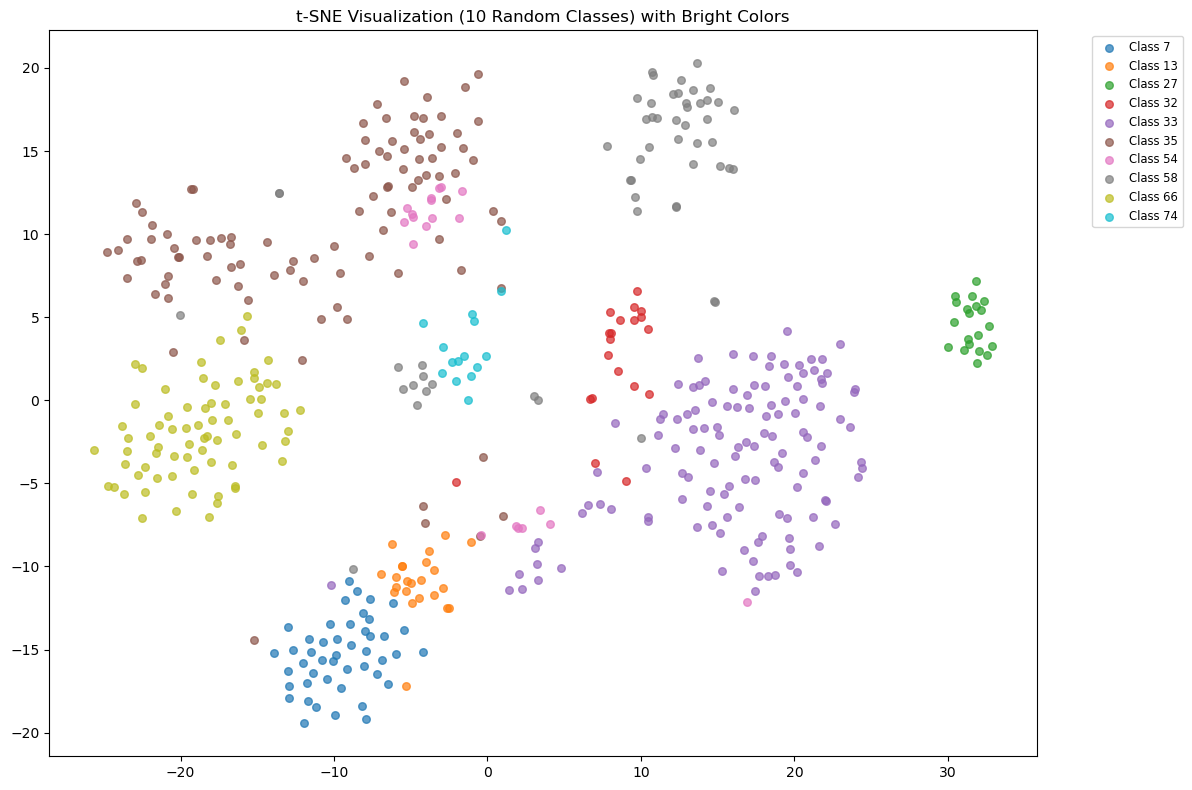

In [12]:
filtered_embeddings_ = all_embeddings_[idx]     # shape: (N_filtered, D)
filtered_labels_ = all_labels_[idx]             # shape: (N_filtered,)

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_2d = tsne.fit_transform(filtered_embeddings_)

plt.figure(figsize=(12, 8))

cmap = plt.cm.get_cmap('tab10', 10)

for i, class_id in enumerate(selected_classes):
    class_idx = (filtered_labels_ == class_id)

    color = cmap(i)
    plt.scatter(X_2d[class_idx, 0],
                X_2d[class_idx, 1],
                label=f"Class {class_id}",
                color=color,
                alpha=0.7,
                s=30)

plt.title("t-SNE Visualization (10 Random Classes) with Bright Colors")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize='small')
plt.tight_layout()
plt.show()

Completed t-SNE, resulting shape: (19494, 2)


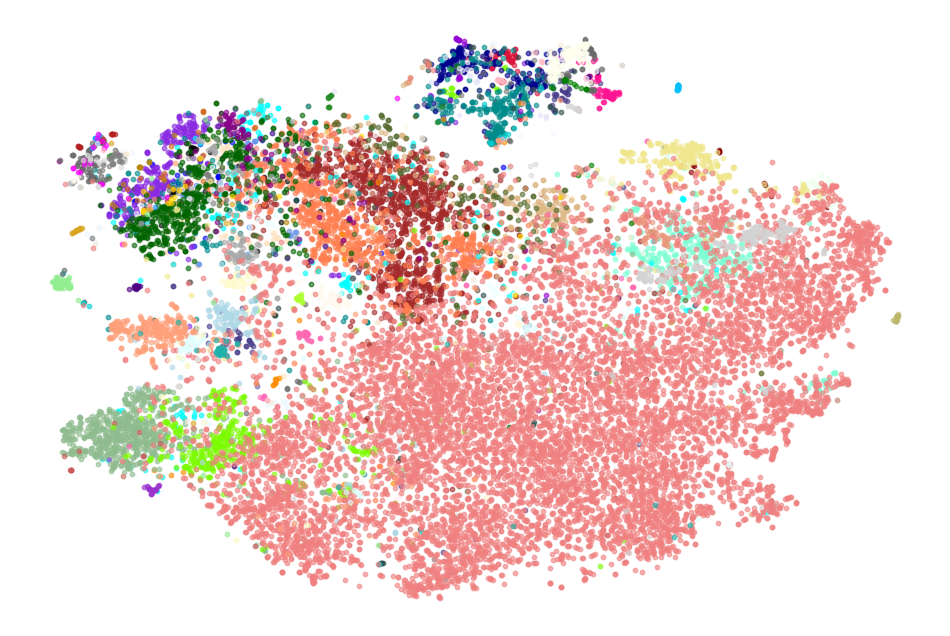

In [11]:
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_2d = tsne.fit_transform(all_embeddings_)  # shape: (N, 2)

print("Completed t-SNE, resulting shape:", X_2d.shape)



plt.figure(figsize=(12, 8))


import matplotlib.colors as mcolors

colors_list = list(mcolors.CSS4_COLORS.keys())  # many color names, but not all are distinct

for class_id in range(NUM_CLASSES):
    idx = (all_labels_ == class_id)
    if np.sum(idx) == 0:
        continue  # no samples of that class
    color = colors_list[class_id % len(colors_list)]  # cycle if needed
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1],
                label=f"Class {class_id}",
                color=color,
                alpha=0.6,
                s=10)

plt.axis('off')
plt.savefig("tsne_no_contr.png", dpi=300, bbox_inches='tight')
plt.show()

In [41]:
selected_classes = random.sample(range(NUM_CLASSES), 10)
selected_classes.sort()  # Optional: sort the classes for consistent ordering

# Filter embeddings and labels for selected classes
indices = np.isin(all_labels, selected_classes)
filtered_embeddings = all_embeddings[indices]
filtered_labels = all_labels[indices]

# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_2d = tsne.fit_transform(filtered_embeddings)

# Plotting
plt.figure(figsize=(12, 8))
colors_list = list(mcolors.CSS4_COLORS.keys())  # Get a list of color names
random.shuffle(colors_list)  # Shuffle to randomize color assignment

for i, class_id in enumerate(selected_classes):
    idx = (filtered_labels == class_id)
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], label=f"Class {class_id}", 
                color=colors_list[i % len(colors_list)], alpha=0.6, s=20)

plt.title("t-SNE visualization of embeddings (selected 10 classes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize='small')
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (610,) + inhomogeneous part.